# **Multipath Fading Characterization of FM Signals Using RTL-SDR**

In this project, envelope data captured from a commercial FM broadcast (93.5 MHz) via an RTL-SDR is processed to characterize small-scale multipath fading: Envelope Extraction, Rayleigh/Rician Distribution Fitting, Fade Depth, Level Crossing Rate (LCR), Average Fade Duration (AFD), Coherence Length, and Doppler Spread.

## Hardware Setup and Data Collection

**Hardware:**
- RTL-SDR dongle (RTL2832U-based) and antenna, tuned to **93.5 MHz** commercial FM broadcast station.
- Host laptop running GNU Radio Companion for real-time capture and pre-processing.

**Signal chain (GNU Radio):**
1. RTL-SDR source captures complex baseband IQ samples at **2.4 MSPS**
2. IQ stream is decimated by **100×** (2.4 MSPS → 24 kSPS) to reduce data rate while still resolving the slow, spatially-driven fading (audio-rate FM content is not of interest here)
3. Instantaneous power is computed as $|x[n]|^2$ from the decimated IQ samples
4. A moving-average filter smooths the power stream to suppress fast audio-rate fluctuations while preserving the slower fading envelope
5. The resulting power stream is logged to a raw binary .bin file (float32, no header)

**Data collection procedure:**
- 5 separate runs were recorded, each ~70–80 s long
- During each run, the receiver was carried at an approximately constant walking pace (~0.8–1.0 m/s) over roughly 20–30 m along an indoor corridor path
- Receiver gain and tuned frequency were held fixed across all runs so results are directly comparable
- Walking speed and distance were estimated (via pacing/timing), not measured with instrumentation — this is the main source of uncertainty in later distance-based quantities (coherence length, Doppler spread)

The rest of this notebook works entirely from the logged .bin files.

Mount Google Drive to access the raw .bin capture files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/FM_Multipath/'

Mounted at /content/drive


Import NumPy/Matplotlib for numerics and plotting, and scipy.stats for Rayleigh/Rician distribution fitting.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Envelope Extraction
The logged data is **instantaneous power**, so the envelope is recovered as $\text{envelope} = \sqrt{\text{power}}$. The first 50 samples are dropped to remove startup transients, and the envelope is normalized by its own mean so runs with different absolute gain settings can be compared on the same scale.

In [ ]:
def plot_envelope(fname, title):
    data = np.fromfile(path + fname, dtype=np.float32)
    data = data[50:]
    envelope = np.sqrt(data)
    envelope_norm = envelope / np.mean(envelope)
    plt.figure(figsize=(12,4))
    plt.plot(envelope_norm)
    plt.title(title)
    plt.xlabel("Sample index")
    plt.ylabel("Normalized amplitude")
    plt.show()
    return envelope_norm

Plot the normalized envelope vs. sample index for all 5 walks. Since the receiver moves at roughly constant walking speed, sample index is effectively a proxy for spatial position. So, these plots show spatial fading, not just fading in time.

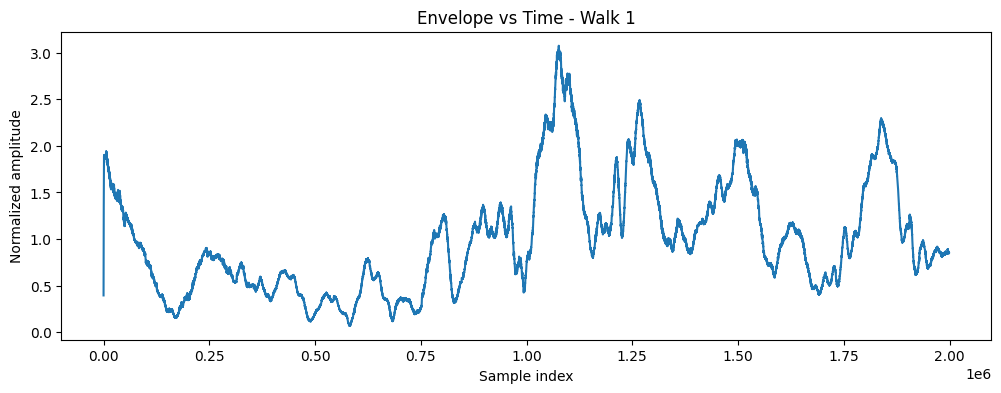

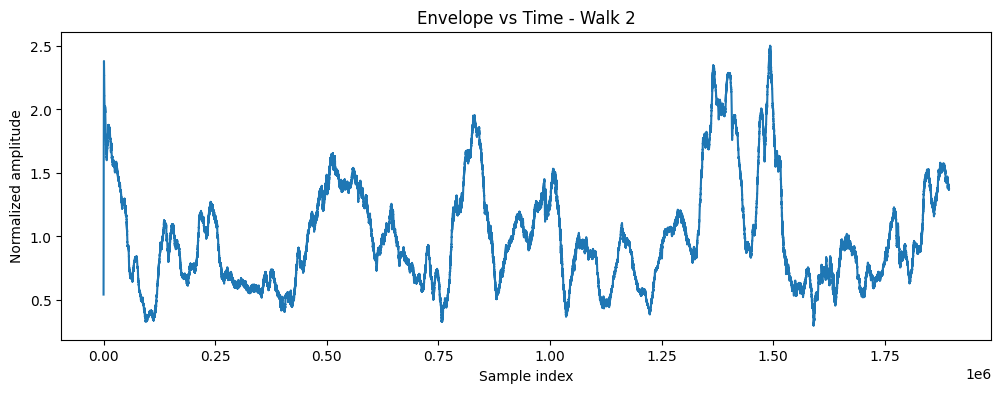

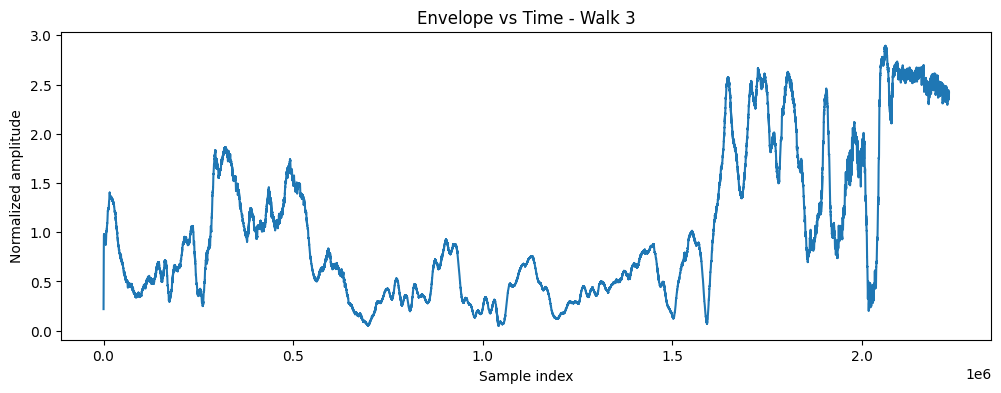

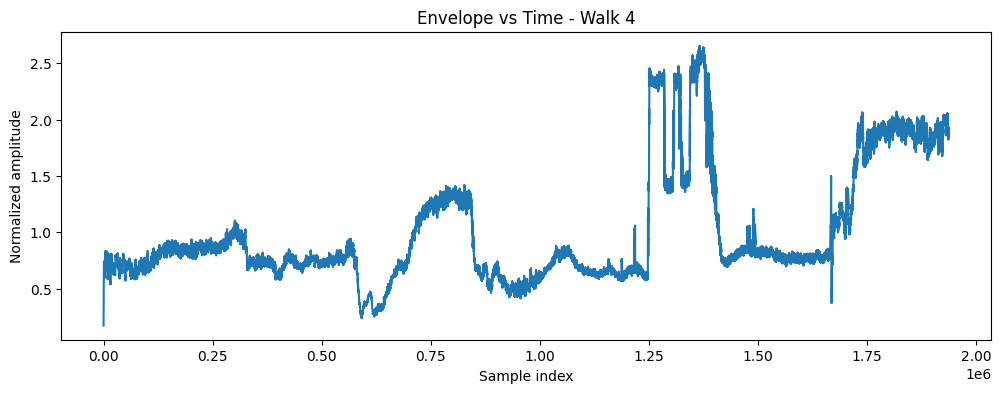

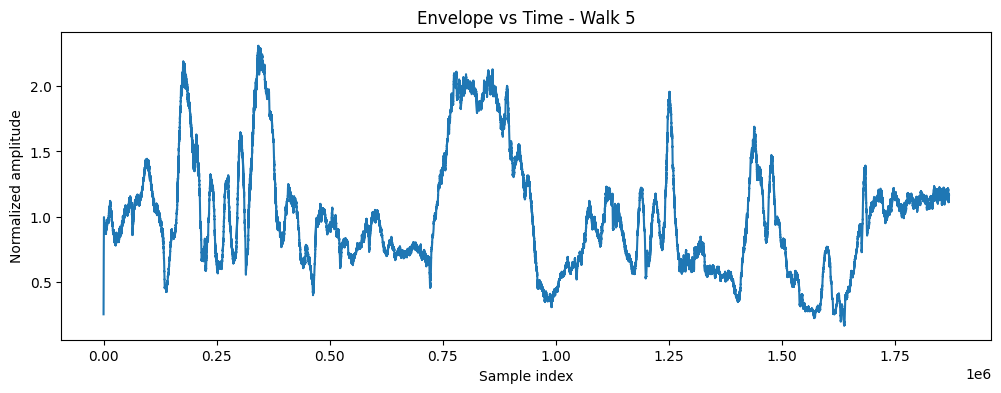

In [ ]:
env1 = plot_envelope('fading_walk1.bin', 'Envelope vs Time - Walk 1')
env2 = plot_envelope('fading_walk2.bin', 'Envelope vs Time - Walk 2')
env3 = plot_envelope('fading_walk3.bin', 'Envelope vs Time - Walk 3')
env4 = plot_envelope('fading_walk4.bin', 'Envelope vs Time - Walk 4')
env4 = plot_envelope('fading_walk5.bin', 'Envelope vs Time - Walk 5')

## Distribution Fitting
Fit the measured envelope histogram against theoretical **Rayleigh** and **Rician** probability density functions (maximum-likelihood fit via scipy.stats), then quantify goodness-of-fit with a **Kolmogorov–Smirnov (KS) test** — a lower KS statistic means the theoretical distribution matches the measured data more closely.

- **Rayleigh** fading arises when there is no dominant path — many comparable-strength multipath components arrive with random phase (NLOS, richly scattering environment).
- **Rician** fading arises when one dominant (e.g., line-of-sight) component exists alongside weaker scattered paths; it reduces to Rayleigh as the dominant component's strength → 0.

In [ ]:
def analyze_envelope(fname, title):
    data = np.fromfile(path + fname, dtype=np.float32)
    data = data[50:]
    envelope = np.sqrt(data)
    envelope_norm = envelope / np.mean(envelope)

    plt.figure(figsize=(8,5))
    plt.hist(envelope_norm, bins=50, density=True, alpha=0.6, label='Measured')

    x = np.linspace(0, max(envelope_norm), 200)
    params_rayleigh = stats.rayleigh.fit(envelope_norm)
    plt.plot(x, stats.rayleigh.pdf(x, *params_rayleigh), label='Rayleigh fit', linewidth=2)

    params_rice = stats.rice.fit(envelope_norm)
    plt.plot(x, stats.rice.pdf(x, *params_rice), label='Rician fit', linewidth=2)

    plt.legend()
    plt.title(f"Envelope Distribution - {title}")
    plt.xlabel("Normalized amplitude")
    plt.ylabel("Density")
    plt.show()

    ks_rayleigh = stats.kstest(envelope_norm, 'rayleigh', args=params_rayleigh)
    ks_rice = stats.kstest(envelope_norm, 'rice', args=params_rice)
    print(f"{title} - Rayleigh KS stat: {ks_rayleigh.statistic:.4f}, Rician KS stat: {ks_rice.statistic:.4f}")

Run the histogram + fit + KS test for all 5 walks.

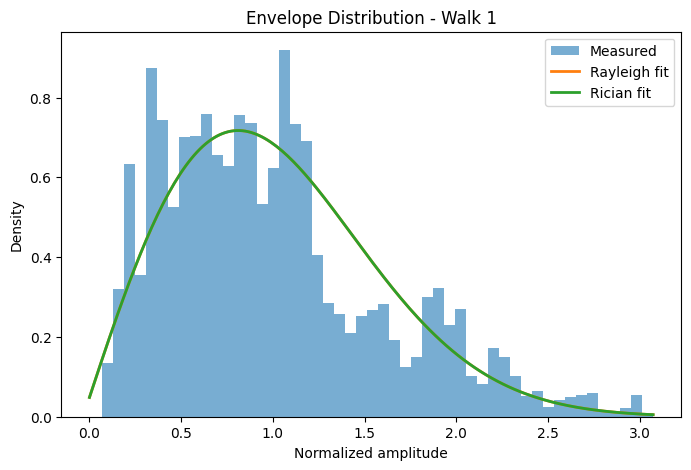

Walk 1 - Rayleigh KS stat: 0.0636, Rician KS stat: 0.0636


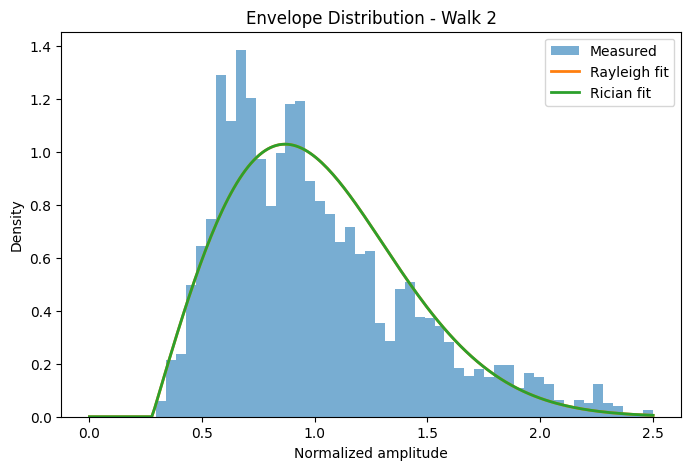

Walk 2 - Rayleigh KS stat: 0.0681, Rician KS stat: 0.0681


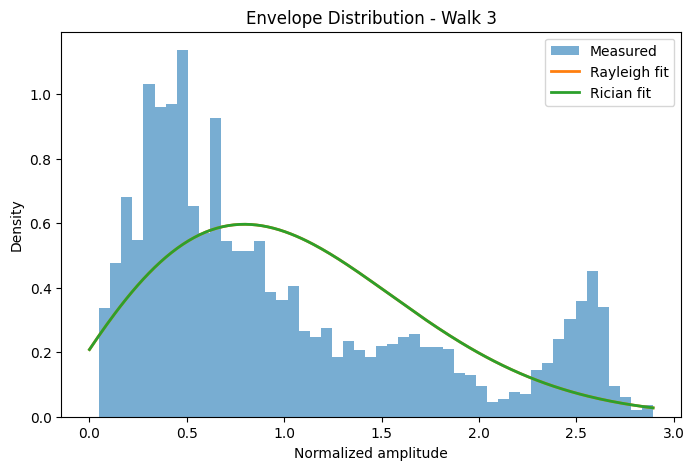

Walk 3 - Rayleigh KS stat: 0.1518, Rician KS stat: 0.1518


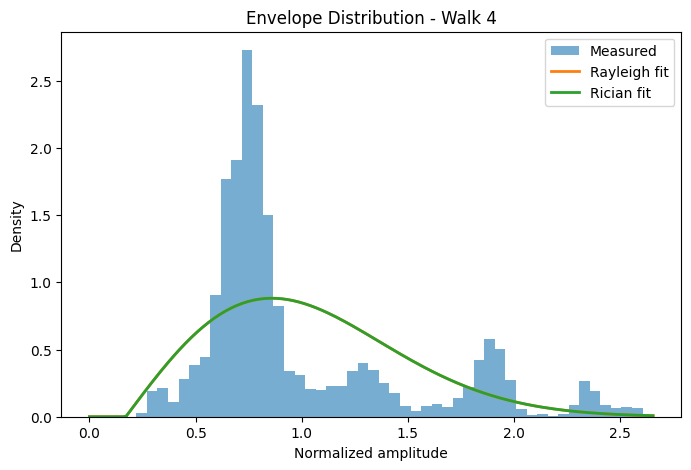

Walk 4 - Rayleigh KS stat: 0.2376, Rician KS stat: 0.2376


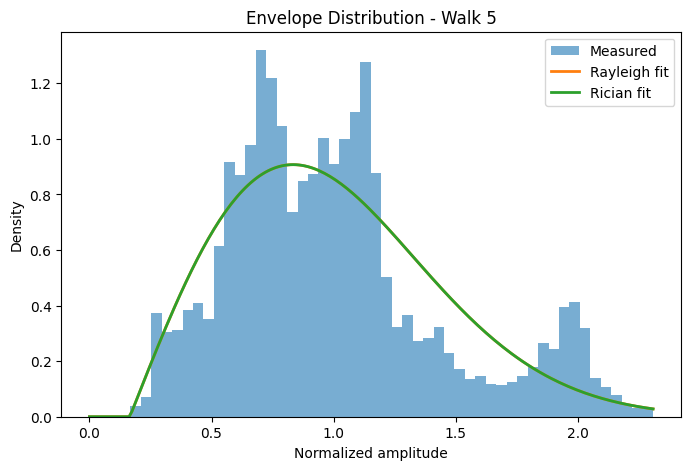

Walk 5 - Rayleigh KS stat: 0.0710, Rician KS stat: 0.0710


In [ ]:
analyze_envelope('fading_walk1.bin', 'Walk 1')
analyze_envelope('fading_walk2.bin', 'Walk 2')
analyze_envelope('fading_walk3.bin', 'Walk 3')
analyze_envelope('fading_walk4.bin', 'Walk 4')
analyze_envelope('fading_walk5.bin', 'Walk 5')

## Fade Depth, Level Crossing Rate, Average Fade Duration
- **Fade depth (dB):** $20\log_{10}(\text{envelope}_{max}/\text{envelope}_{min})$ — the dynamic range of the fading over the run.
- **Level Crossing Rate (LCR):** how often the envelope crosses the mean level (threshold = 1.0) in the upward direction, normalized per sample — a higher LCR means faster/denser fading.
- **Average Fade Duration (AFD):** mean length (in samples) of the intervals the envelope spends below the threshold — how long each fade dip lasts on average.

In [ ]:
def extended_analysis(fname, title, threshold=1.0):
    data = np.fromfile(path + fname, dtype=np.float32)
    data = data[50:]
    envelope = np.sqrt(data)
    envelope_norm = envelope / np.mean(envelope)

    # Fade depth (dB)
    fade_depth = 20*np.log10(envelope_norm.max()/envelope_norm.min())

    # Level Crossing Rate (crossings of mean level, per sample)
    crossings = np.sum((envelope_norm[:-1] < threshold) & (envelope_norm[1:] >= threshold))
    lcr = crossings / len(envelope_norm)

    # Average Fade Duration (avg length of runs below threshold)
    below = envelope_norm < threshold
    fade_runs = []
    count = 0
    for b in below:
        if b:
            count += 1
        else:
            if count > 0:
                fade_runs.append(count)
            count = 0
    afd = np.mean(fade_runs) if fade_runs else 0

    print(f"{title}: Fade depth = {fade_depth:.2f} dB, LCR = {lcr:.5f} crossings/sample, AFD = {afd:.2f} samples")
    return fade_depth, lcr, afd

results = []
for i in range(1,6):
    r = extended_analysis(f'fading_walk{i}.bin', f'Walk {i}')
    results.append(r)

Walk 1: Fade depth = 32.86 dB, LCR = 0.00003 crossings/sample, AFD = 16995.77 samples
Walk 2: Fade depth = 18.51 dB, LCR = 0.00011 crossings/sample, AFD = 5416.76 samples
Walk 3: Fade depth = 35.28 dB, LCR = 0.00002 crossings/sample, AFD = 31159.07 samples
Walk 4: Fade depth = 23.81 dB, LCR = 0.00007 crossings/sample, AFD = 9740.81 samples
Walk 5: Fade depth = 22.80 dB, LCR = 0.00014 crossings/sample, AFD = 4114.97 samples


## Coherence Length and Doppler Spread
Envelope autocorrelation is computed via the FFT, avoiding a direct $O(n^2)$ correlation sum.

- **Coherence length:** the spatial lag at which the normalized autocorrelation first falls below 0.5 — beyond this displacement, the channel is effectively decorrelated.
- **Reference:** FM wavelength at 93.5 MHz is $\lambda = c/f \approx 3.2$ m. Coherence length much smaller than $\lambda$ indicates fast spatial decorrelation, consistent with a rich-multipath indoor channel.

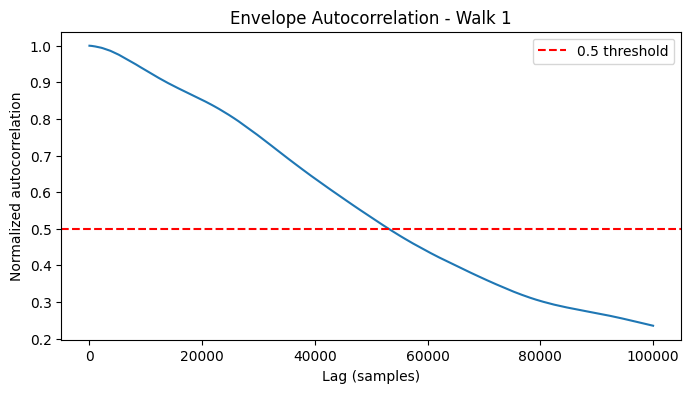

Walk 1: Coherence length ≈ 53065 samples (2.211 s, 0.737 m)


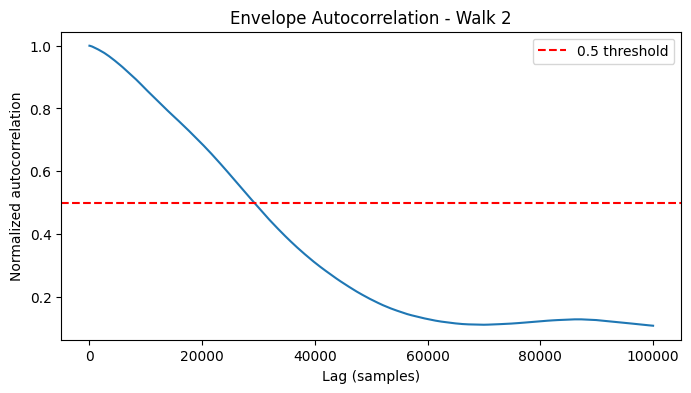

Walk 2: Coherence length ≈ 29214 samples (1.217 s, 0.406 m)


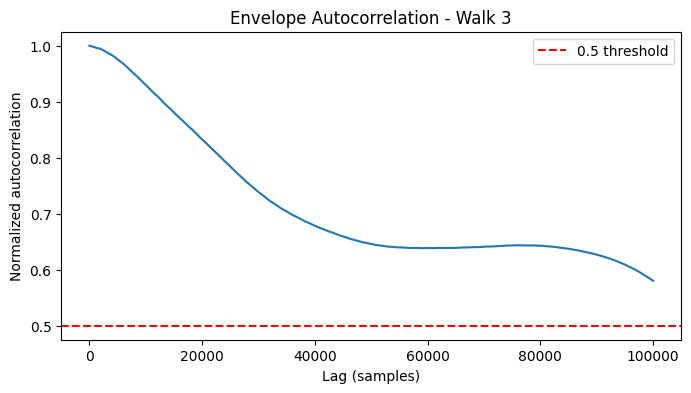

Walk 3: Coherence length > 100000 samples (didn't drop below 0.5)


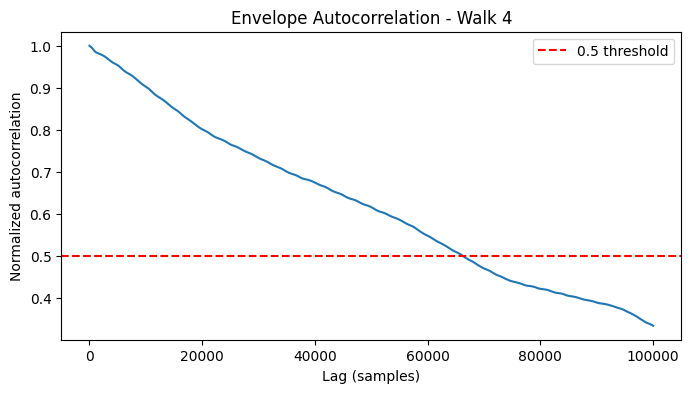

Walk 4: Coherence length ≈ 66276 samples (2.761 s, 0.920 m)


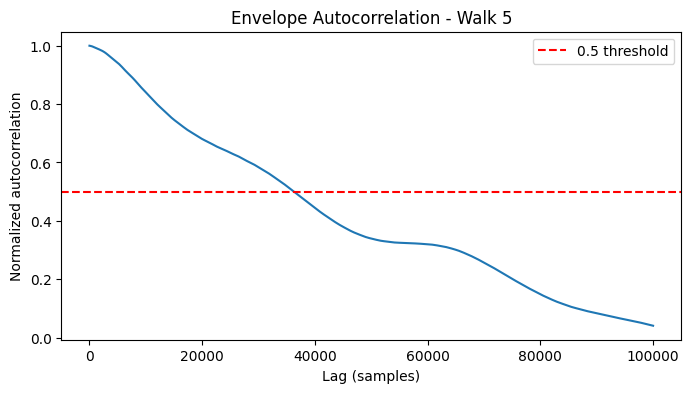

Walk 5: Coherence length ≈ 36265 samples (1.511 s, 0.504 m)


In [ ]:
sample_rate = 24000    # samples/sec
distance_walked = 25   # meters (approx)
walk_duration = 75     # seconds (approx)
speed = distance_walked / walk_duration   # m/s

def coherence_plot_fft(fname, title, max_lag=100000):
    data = np.fromfile(path + fname, dtype=np.float32)
    data = data[50:]
    envelope = np.sqrt(data)
    envelope_norm = envelope / np.mean(envelope)
    envelope_norm = envelope_norm - np.mean(envelope_norm)

    n = len(envelope_norm)
    fft_vals = np.fft.fft(envelope_norm, n=2*n)
    power_spectrum = fft_vals * np.conj(fft_vals)
    autocorr = np.fft.ifft(power_spectrum).real
    autocorr = autocorr[:n]
    autocorr /= autocorr[0]

    plt.figure(figsize=(8,4))
    plt.plot(autocorr[:max_lag])
    plt.axhline(y=0.5, color='r', linestyle='--', label='0.5 threshold')
    plt.title(f"Envelope Autocorrelation - {title}")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Normalized autocorrelation")
    plt.legend()
    plt.show()

    below_half = np.where(autocorr[:max_lag] < 0.5)[0]
    coh_samples = below_half[0] if len(below_half) > 0 else None

    if coh_samples is not None:
        coh_time = coh_samples / sample_rate
        coh_length = coh_time * speed
        print(f"{title}: Coherence length ≈ {coh_samples} samples "
              f"({coh_time:.3f} s, {coh_length:.3f} m)")
    else:
        print(f"{title}: Coherence length > {max_lag} samples (didn't drop below 0.5)")
        coh_time, coh_length = None, None

    return coh_samples, coh_time, coh_length


for i in range(1, 6):
    coherence_plot_fft(f'fading_walk{i}.bin', f'Walk {i}')

## Summary Table
Consolidates Fade Depth, LCR, AFD, Coherence Time/Length, Doppler Spread, and Rayleigh/Rician KS statistics across all 5 walks. Doppler Spread is estimated from Coherence Time using the standard inverse relationship $B_D \approx \dfrac{1}{2\pi T_c}$.

In [ ]:
import pandas as pd

results_table = []

for i in range(1, 6):
    fname = f'fading_walk{i}.bin'
    title = f'Walk {i}'

    data = np.fromfile(path + fname, dtype=np.float32)
    data = data[50:]
    envelope = np.sqrt(data)
    envelope_norm = envelope / np.mean(envelope)

    # Rayleigh/Rician KS
    params_rayleigh = stats.rayleigh.fit(envelope_norm)
    params_rice = stats.rice.fit(envelope_norm)
    ks_rayleigh = stats.kstest(envelope_norm, 'rayleigh', args=params_rayleigh).statistic
    ks_rice = stats.kstest(envelope_norm, 'rice', args=params_rice).statistic

    # Fade Depth
    fade_depth = 20*np.log10(envelope_norm.max()/envelope_norm.min())

    # LCR & AFD
    threshold = 1.0
    crossings = np.sum((envelope_norm[:-1] < threshold) & (envelope_norm[1:] >= threshold))
    lcr = crossings / len(envelope_norm)
    below = envelope_norm < threshold
    fade_runs, count = [], 0
    for b in below:
        if b:
            count += 1
        else:
            if count > 0:
                fade_runs.append(count)
            count = 0
    afd = np.mean(fade_runs) if fade_runs else 0

    # Coherence
    envelope_centered = envelope_norm - np.mean(envelope_norm)
    n = len(envelope_centered)
    fft_vals = np.fft.fft(envelope_centered, n=2*n)
    power_spectrum = fft_vals * np.conj(fft_vals)
    autocorr = np.fft.ifft(power_spectrum).real[:n]
    autocorr /= autocorr[0]
    below_half = np.where(autocorr[:100000] < 0.5)[0]
    coh_samples = below_half[0] if len(below_half) > 0 else None

    if coh_samples is not None:
        coh_time = coh_samples / sample_rate
        coh_length = coh_time * speed
        doppler_spread = 1 / (2 * np.pi * coh_time)
    else:
        coh_time, coh_length, doppler_spread = None, None, None

    results_table.append({
        'Walk': title,
        'Fade Depth (dB)': round(fade_depth, 2),
        'LCR (crossings/sample)': round(lcr, 5),
        'AFD (samples)': round(afd, 2),
        'Coherence Time (s)': round(coh_time, 3) if coh_time else None,
        'Coherence Length (m)': round(coh_length, 3) if coh_length else None,
        'Doppler Spread (Hz)': round(doppler_spread, 3) if doppler_spread else None,
        'Rayleigh KS': round(ks_rayleigh, 4),
        'Rician KS': round(ks_rice, 4)
    })

df = pd.DataFrame(results_table)
df

,Walk,Fade Depth (dB),LCR (crossings/sample),AFD (samples),Coherence Time (s),Coherence Length (m),Doppler Spread (Hz),Rayleigh KS,Rician KS
0,Walk 1,32.860001,0.00003,16995.77,2.211,0.737,0.072,0.0636,0.0636
1,Walk 2,18.510000,0.00011,5416.76,1.217,0.406,0.131,0.0681,0.0681
2,Walk 3,35.279999,0.00002,31159.07,NaN,NaN,NaN,0.1518,0.1518
3,Walk 4,23.809999,0.00007,9740.81,2.762,0.920,0.058,0.2376,0.2376
4,Walk 5,22.799999,0.00014,4114.97,1.511,0.504,0.105,0.0710,0.0710


## Results, Interpretation, and Conclusions

**Rayleigh vs. Rician**: KS statistics identical across all walks — Rician fit collapses to Rayleigh, no benefit from a dominant component.

**Fit quality**: Walk 4 worst (KS 0.2376), Walks 1/2/5 best (KS ≈0.06–0.07), Walk 3 mid (0.1518).

**Fade depth**: 18.5–35.3 dB range (Walk 2 → Walk 3). Need ~20–35 dB fade margin.

**LCR/AFD**: LCR ~10⁻⁵ crossings/sample (slow, spatial fading, not fast noise). AFD in thousands–tens of thousands of samples. Walk 3: lowest LCR, highest AFD, deepest fade — one long deep null.

**Coherence length**: 0.41–0.92 m (4 walks) vs. λ≈3.2 m at 93.5 MHz — fast spatial decorrelation, rich multipath. Walk 3 = NaN (autocorrelation never dropped below 0.5; matches its high AFD).

**Doppler spread**: 0.058–0.131 Hz, inversely tracks coherence time (Walk 2 max, Walk 4 min).

**Conclusion**: Corridor path is NLOS, richly-scattering, well-modeled by Rayleigh fading (KS 0.06–0.24, no Rician improvement, coherence lengths ≪ λ). RTL-SDR produces physically consistent results, with expected run-to-run variation (Walk 4 fit, Walk 3 coherence).

**Caveat**: Walking speed = distance/duration (estimated, not measured). ±20% speed error → same % error in coherence length and Doppler spread (both scale linearly with speed). Coherence time (seconds) is unaffected and reliable.